In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.utils import resample
from scipy.stats import shapiro, mannwhitneyu

In [ ]:
match_data = pd.read_csv('match_data.csv')
match_info_data = pd.read_csv('match_info_data.csv')
match_data.head()

/tmp/ipython-input-2-3285161557.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  match_data = pd.read_csv('match_data.csv')


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,...,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed,cricsheet_id
0,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.1,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353.0
1,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.2,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353.0
2,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.3,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353.0
3,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.4,Gujarat Titans,Chennai Super Kings,Shubman Gill,WP Saha,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353.0
4,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",1,0.5,Gujarat Titans,Chennai Super Kings,WP Saha,Shubman Gill,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1370353.0


In [ ]:
# Enhanced Data Cleaning $ Feature Engineering
match_info_data['date'] = pd.to_datetime(match_info_data['date'], errors = 'coerce')
errors = 'coerce'
team_runs_per_match = match_data.groupby(['match_id', 'batting_team'])['runs_off_bat'].sum().reset_index()
team_runs_per_match.rename(columns={'runs_off_bat': 'total_runs'}, inplace=True)
merged = pd.merge(team_runs_per_match, match_info_data[['id', 'date', 'venue', 'team1', 'team2']], left_on = 'match_id', right_on = 'id')
merged.drop(columns=['id'], inplace=True)
merged['Period'] = merged['date'].dt.year.apply(lambda x: 'Pre' if x < 2018 else 'Post')
merged['run_rate'] = merged['total_runs'] / 20.0
merged['year'] = merged['date'].dt.year

In [ ]:
merged.head()

,match_id,batting_team,total_runs,date,venue,team1,team2,Period,run_rate,year
0,829723,Chennai Super Kings,145.0,2015-04-30,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Pre,7.25,2015
1,829723,Kolkata Knight Riders,159.0,2015-04-30,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Pre,7.95,2015
2,829747,Delhi,0.0,2015-04-23,Feroz Shah Kotla,Delhi Daredevils,Mumbai Indians,Pre,0.00,2015
3,829747,Delhi Daredevils,103.0,2015-04-23,Feroz Shah Kotla,Delhi Daredevils,Mumbai Indians,Pre,5.15,2015
4,829749,Rajasthan Royals,126.0,2015-04-24,"Sardar Patel Stadium, Motera",Rajasthan Royals,Royal Challengers Bangalore,Pre,6.30,2015


In [ ]:
stat, p = shapiro(merged[merged['Period'] == 'post']['total_runs'])
print(f"Shapiro-Wilk Test: p = {p}")

Shapiro-Wilk Test: p = nan


/tmp/ipython-input-5-1389871478.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(merged[merged['Period'] == 'post']['total_runs'])


In [ ]:
# Normality Tests
pre_scores = merged[merged['Period'] == 'pre']['total_runs']
post_scores = merged[merged['Period'] == 'post']['total_runs']
pre_normalty = shapiro(pre_scores.sample(n=500, random_state = 1) if len(pre_scores) > 500 else pre_scores)
post_normalty = shapiro(post_scores.sample(n=500, random_state = 1) if len(post_scores) > 500 else post_scores)
print("Shapiro-Wilk Test (pre):", pre_normalty)
print("Shapiro-Wilk Test (post):", post_normalty)

Shapiro-Wilk Test (pre): ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))
Shapiro-Wilk Test (post): ShapiroResult(statistic=np.float64(nan), pvalue=np.float64(nan))


/tmp/ipython-input-7-2874104454.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  pre_normalty = shapiro(pre_scores.sample(n=500, random_state = 1) if len(pre_scores) > 500 else pre_scores)
/tmp/ipython-input-7-2874104454.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  post_normalty = shapiro(post_scores.sample(n=500, random_state = 1) if len(post_scores) > 500 else post_scores)


In [ ]:
match_counts = match_info_data.groupby(match_info_data['date'].dt.year)['id'].nunique().reset_index()
match_counts.columns = ['season', 'match_count']
match_info_data['season'] = match_info_data['date'].dt.year
match_info_data['match_number'] = match_info_data.groupby('season')['date'].rank(method='first', ascending=True)
match_counts.set_index('season', inplace=True)
match_info_data['match_count'] = match_info_data['season'].map(match_counts['match_count'])
match_info_data['is_playoff'] = match_info_data['match_number'] > (match_info_data['match_count'] - 4)
merged = pd.merge(merged, match_info_data[['id', 'is_playoff']], left_on = 'match_id', right_on = 'id')
merged.drop(columns=['id'], inplace=True)

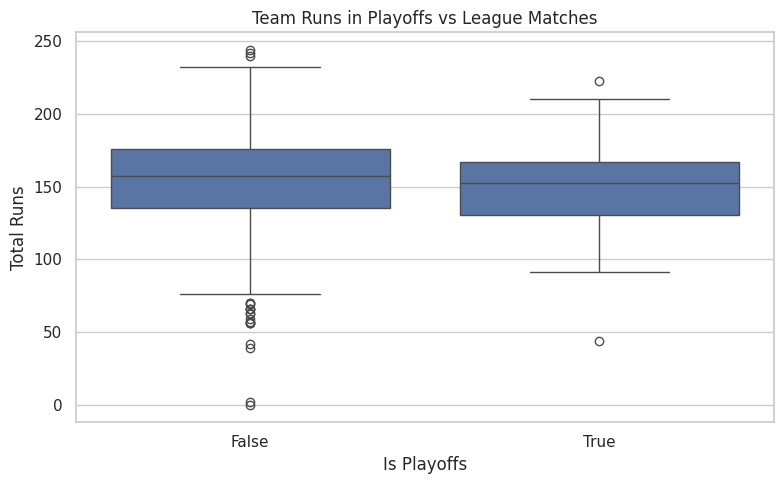

In [ ]:
# Set plot style
sns.set(style="whitegrid")

# 1. Average Runs in playoffs vs League Matches
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x='is_playoff', y='total_runs')
plt.title("Team Runs in Playoffs vs League Matches")
plt.xlabel("Is Playoffs")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

In [ ]:
# Separated scores into te=wo groups based on is_playoff flag
league_scores = merged[merged['is_playoff'] == False]['total_runs']
playoff_scores = merged[merged['is_playoff'] == True]['total_runs']

# Run the Mann-Whitney U test(non-parametric test for median differences)
u_statistic, p_value = mannwhitneyu(league_scores, playoff_scores, alternative='two-sided')

# Display results
print(f"Mann-Whitney U Statistics: {u_statistic}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("The difference in scores between league matches and playoff matches is statistically significant.")
else:
    print("There is no statistically significant difference in scores between league matches and playoff matches.")

Mann-Whitney U Statistics: 40736.0
P-value: 0.11330264017148979
There is no statistically significant difference in scores between league matches and playoff matches.


In [ ]:
# Choose your team name
team_name =  "Chennai Super Kings"

#Filter only this team's matches

team_data  = merged [merged['batting_team'] == team_name]
# Separate scores by match type

League_scores  = team_data[team_data['is_playoff'] ==False]['total_runs']
playoff_scores  = team_data[team_data['is_playoff']==True]['total_runs']

# Mann-whitney U Test
u_statistic, p_value = mannwhitneyu(league_scores, playoff_scores, alternative = 'two-sided')

#Print results

print(f"Team: (team_name)")

print(f"Mann-Whitney U Statistic: (u_statistic)")

print("P-value: (p_value)")

if p_value < 0.05:
    print(" This team shows a statistically significant scoring difference in playoffs vs league matches.")
else:
    print("X No statistically significant scoring difference for this tean.")

Team: (team_name)
Mann-Whitney U Statistic: (u_statistic)
P-value: (p_value)
X No statistically significant scoring difference for this tean.


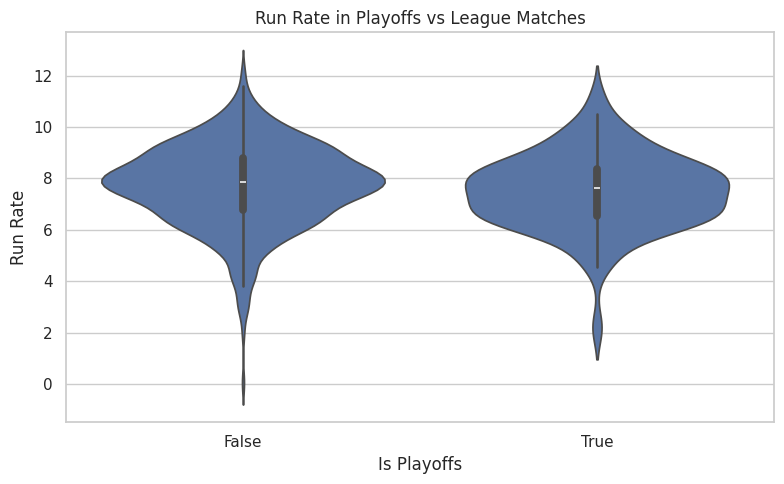

In [ ]:
# Run rate Trends in playoff vs League Matches
plt.figure(figsize=(8, 5))
sns.violinplot(data=merged, x='is_playoff', y='run_rate')
plt.title("Run Rate in Playoffs vs League Matches")
plt.xlabel("Is Playoffs")
plt.ylabel("Run Rate")
plt.tight_layout()
plt.show()

In [ ]:
# Home vs Away flags
merged['home_team'] = merged['batting_team'] == merged['team1']
merged['away_team'] = merged['batting_team'] == merged['team2']
homw_away_df = merged.melt(
    id_vars=['total_runs'],
    value_vars=['home_team', 'away_team'],
    var_name='location',
    value_name='is_true'
)

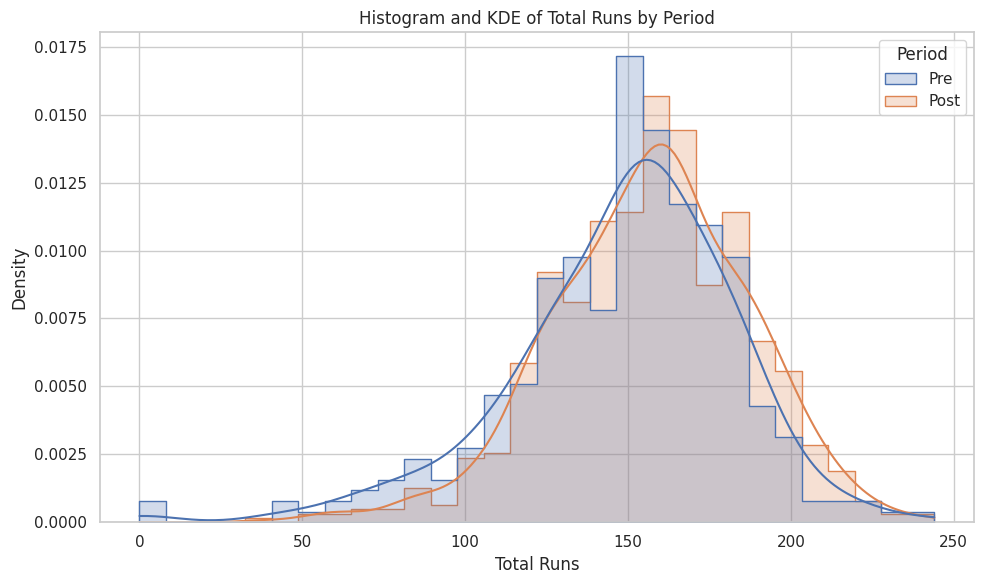

In [ ]:
# Diatribution plots
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.histplot(data=merged, x='total_runs', hue='Period', element='step', stat='density', common_norm=False, kde=True, bins=30)
plt.title("Histogram and KDE of Total Runs by Period")
plt.xlabel("Total Runs")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The goal is to prepare the datasetto compare total runs scored in home matches vs away matches

In [ ]:
match_data = pd.read_csv('match_data.csv')
match_info_data = pd.read_csv('match_info_data.csv')
match_info_data['date'] = pd.to_datetime(match_info_data['date'], errors = 'coerce')
errors = 'coerce'
team_runs_per_match = match_data.groupby(['match_id', 'batting_team'])['runs_off_bat'].sum().reset_index()
team_runs_per_match.rename(columns={'runs_off_bat': 'total_runs'}, inplace=True)
merged = pd.merge(team_runs_per_match, match_info_data[['id', 'date', 'venue', 'team1', 'team2']], left_on = 'match_id', right_on = 'id')
merged.drop(columns=['id'], inplace=True)
merged['Period'] = merged['date'].dt.year.apply(lambda x: 'Pre' if x < 2018 else 'Post')
merged['run_rate'] = merged['total_runs'] / 20.0
merged['year'] = merged['date'].dt.year
# Home vs Away flags
merged['home_team'] = merged['batting_team'] == merged['team1']
merged['away_team'] = merged['batting_team'] == merged['team2']

/tmp/ipython-input-22-1611680620.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  match_data = pd.read_csv('match_data.csv')


In [ ]:
import pandas as pd

In [ ]:
match_counts = match_info_data.groupby(match_info_data['date'].dt.year)['id'].nunique().reset_index()
match_counts.columns = ['season', 'match_count']
match_info_data['season'] = match_info_data['date'].dt.year
match_info_data['match_number'] = match_info_data.groupby('season')['date'].rank(method='first', ascending=True)
match_counts.set_index('season', inplace=True)
match_info_data['match_count'] = match_info_data['season'].map(match_counts['match_count'])
match_info_data['is_playoff'] = match_info_data['match_number'] > (match_info_data['match_count'] - 4)
merged = pd.merge(merged, match_info_data[['id', 'is_playoff']], left_on = 'match_id', right_on = 'id')
merged.drop(columns=['id'], inplace=True)
# Home vs Away flags
merged['home_team'] = merged['batting_team'] == merged['team1']
merged['away_team'] = merged['batting_team'] == merged['team2']

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
# Step1: Import the necessary library
# Step 2: Split the run data based on is_playoff

league_run_rates = merged[merged['is_playoff'] == False]['run_rate']
playoff_run_rates = merged[merged['is_playoff'] == True]['run_rate']

# Step 3: Run the Mann-Whitney Utest
u_statistic, p_value = mannwhitneyu(league_run_rates, playoff_run_rates, alternative='two-sided')

# Step 4: Print the results
print(f"Mann-Whitney U Statistics: {u_statistic}")
print(f"P-value: {p_value}")

# Step 5: Interpret the result
if p_value < 0.05:
    print("The difference in run rates between league matches and playoff matches is statistically significant.")
else:
    print("There is no statistically significant difference in run rates between league matches and playoff matches.")

Mann-Whitney U Statistics: 124606.0
P-value: 0.7668706992141119
There is no statistically significant difference in run rates between league matches and playoff matches.


In [ ]:
# Normality Tests
pre_scores = merged[merged['Period'] == 'Pre']['total_runs']
post_scores = merged[merged['Period'] == 'Post']['total_runs']

In [ ]:
# Hypothesis Testing
import numpy as np
u_stat, p_val = mannwhitneyu(pre_scores, post_scores, alternative='two-sided')
print(f"Mann-Whitney U Test: U-statistic = {u_stat}, p-value = {p_val}")

def cohen_d(x,y):
 nx = len(x)
 ny = len(y)
 dof = nx + ny - 2
 pooland_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
 return (np.mean(x) - np.mean(y)) / pooland_std

effect_size = cohen_d(pre_scores, post_scores)
print(f"Cohen's d: {effect_size}")

Mann-Whitney U Test: U-statistic = 381621.5, p-value = 1.454889995517028e-17
Cohen's d: -0.3901739611740549


In [ ]:
# Bootstrap confidence interval
from sklearn.utils import resample

def Bootstrap_diff_means(x,y,n_bootstrap=1000):
  diffs = [np.mean(resample(y)) - np.mean(resample(x)) for _ in range(n_bootstrap)]
  return np.percentile(diffs, [2.5, 97.5]), np.mean(diffs)

ci_bounds, mean_diff = Bootstrap_diff_means(pre_scores, post_scores)
print("95% confidence interval:", ci_bounds, "\nMean Difference:", mean_diff)

95% confidence interval: [ 9.12850927 14.52329578] 
Mean Difference: 11.896757068834136


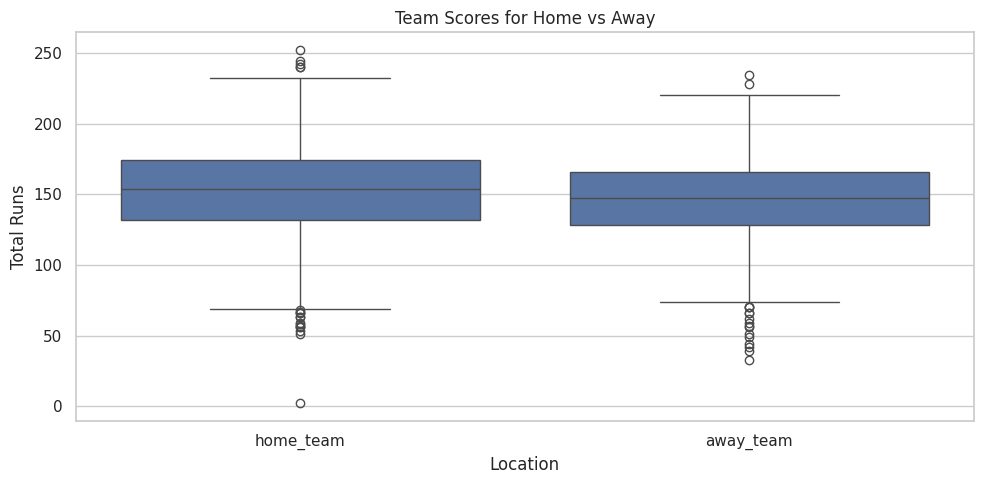

In [ ]:
# Average runs for home as away
# Melt the dataset to reshape to reshape for home vs away comparison
home_away_df =  merged.melt(id_vars=['total_runs'], value_vars=['home_team', 'away_team'],
                            var_name='location', value_name='is_true')

# Filter for only the rows where the condition (home/away) is true
home_away_df = home_away_df[home_away_df['is_true'] == True]

plt.figure(figsize=(10,5))
sns.boxplot(data=home_away_df, x='location', y='total_runs')
plt.title("Team Scores for Home vs Away")
plt.xlabel("Location")
plt.ylabel("Total Runs")
plt.tight_layout()
plt.show()

In [ ]:
# import the statistical test
from scipy.stats import mannwhitneyu

# step 1: Extract the two groups
home_scores = home_away_df[home_away_df['location'] == 'home_team']['total_runs']
away_scores = home_away_df[home_away_df['location'] == 'away_team']['total_runs']

# step 2: Runs the Mann-Whitney
u_statistic, p_value = mannwhitneyu(home_scores, away_scores, alternative='two-sided')

# step 3: Print the results
print(f"Mann-Whitney U Statistics: {u_statistic}")
print(f"P-value: {p_value}")

# step 4: Interpret the result
print("Interpretation:")
if p_value < 0.05:
    print("The difference in scores between home and away matches is statistically significant.")
else:
    print("There is no statistically significant difference in scores between home and away matches.")

Mann-Whitney U Statistics: 581106.0
P-value: 1.2376099361250964e-05
Interpretation:
The difference in scores between home and away matches is statistically significant.


In [ ]:
# show the number of missing values in each column
print("Number of missing values in each column:")
print(merged.isnull().sum())

# check if Any missing values exist
print("Check if Any missing values exist:")
print(merged.isnull().values.any())

# perecent of missing values per column
print("Percent of missing values per column")
missing_percent = merged.isnull().mean() * 100
print(missing_percent)

# Show just the rows that have any missing data
print("Show Just yhe rows that have any missing data")
missing_rows = merged [merged.isnull().any(axis=1)]
print(missing_rows.head())

Number of missing values in each column:
match_id        0
batting_team    0
total_runs      0
date            0
venue           0
team1           0
team2           0
Period          0
run_rate        0
year            0
home_team       0
away_team       0
is_playoff      0
dtype: int64
Check if Any missing values exist:
False
Percent of missing values per column
match_id        0.0
batting_team    0.0
total_runs      0.0
date            0.0
venue           0.0
team1           0.0
team2           0.0
Period          0.0
run_rate        0.0
year            0.0
home_team       0.0
away_team       0.0
is_playoff      0.0
dtype: float64
Show Just yhe rows that have any missing data
Empty DataFrame
Columns: [match_id, batting_team, total_runs, date, venue, team1, team2, Period, run_rate, year, home_team, away_team, is_playoff]
Index: []


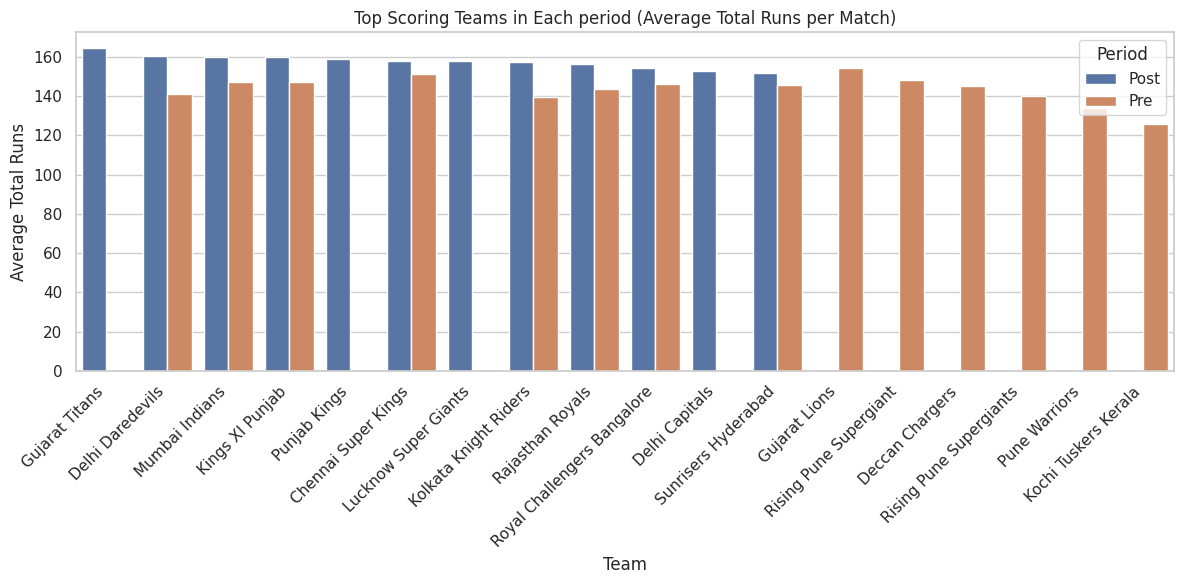

In [ ]:
# Group by team and period to calculate average total runs per match
top_scoring_teams = (
    merged.groupby(['batting_team', 'Period'])['total_runs']
    .mean()
    .reset_index()
    .sort_values(by=['Period', 'total_runs'], ascending=[True, False])
)

# plot the result using a barplot
plt.figure(figsize=(12,6))
sns.barplot(data=top_scoring_teams, x='batting_team', y='total_runs', hue='Period')

# Beautify the plot
plt.title("Top Scoring Teams in Each period (Average Total Runs per Match)")
plt.ylabel("Average Total Runs")
plt.xlabel("Team")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

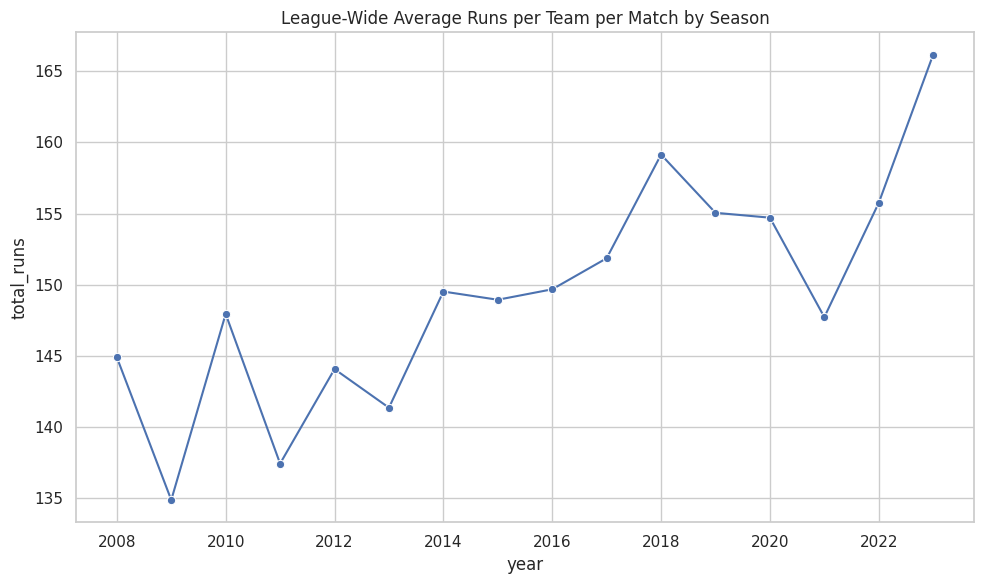

In [ ]:
seasonal_avg = merged.groupby('year')['total_runs'].mean().reset_index()
plt.figure(figsize=(10, 6)),
sns.lineplot(data=seasonal_avg, x='year', y='total_runs', marker='o')
plt.title("League-Wide Average Runs per Team per Match by Season")
plt.grid(True)
plt.tight_layout()
plt.show()